# Advanced Analytics — Day 6 Capstone
**Bluestock Fintech | Mutual Fund Analytics**

This notebook synthesises all Day 6 advanced analytics outputs into a single, readable report.
All computations were run via dedicated scripts in `scripts/`; this notebook **loads and displays** results.

---
**Deliverables Covered:**
1. Historical VaR (95%) & CVaR → `var_cvar_report.csv`
2. Rolling 90-Day Sharpe Ratio → `rolling_sharpe_chart.png`
3. Investor Cohort Analysis → `cohort_analysis.csv`
4. SIP Continuity Analysis → `sip_continuity.csv`
5. Sector Concentration (HHI) → `sector_hhi.csv` + `sector_hhi_chart.png`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
import os

warnings.filterwarnings('ignore')

# Base path resolution
BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

def load(filename, folder='data/processed'):
    """Load a processed CSV by filename."""
    return pd.read_csv(os.path.join(BASE, folder, filename))

def embed_image(filename, folder='notebooks/reports', figsize=(14, 7), title=''):
    """Display a saved chart image inline."""
    path = os.path.join(BASE, folder, filename)
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.show()

print('✅ Imports ready. BASE =', BASE)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ Imports ready. BASE = /Users/subhasish/bluestock_mf_capstone


---
## Section 1 — Historical Value at Risk (VaR 95%) & CVaR

**Method:** Historical simulation using daily NAV returns.
- **VaR (95%)** = 5th percentile of daily return distribution — the maximum daily loss at 95% confidence.
- **CVaR (Expected Shortfall)** = mean of all returns *at or below* the VaR threshold — measures severity of tail losses.

**Formula:**
```
VaR   = np.percentile(daily_returns, 5)
CVaR  = daily_returns[daily_returns <= VaR].mean()
```

In [2]:
var_df = load('var_cvar_report.csv')

# Convert to percentage for display
display_df = var_df.copy()
display_df['VaR 95% (%)']  = (display_df['var_95_pct'] * 100).round(3)
display_df['CVaR 95% (%)'] = (display_df['cvar_95_pct'] * 100).round(3)
display_df['Ann. VaR (%)'] = (display_df['annualised_var_pct'] * 100).round(3)

print(f'Total funds analysed: {len(var_df)}')
print('\n--- Full VaR / CVaR Report (sorted: riskiest first) ---')
display_df[['scheme_name', 'category', 'risk_grade',
            'VaR 95% (%)', 'CVaR 95% (%)', 'Ann. VaR (%)']].to_string(index=False)

Total funds analysed: 40

--- Full VaR / CVaR Report (sorted: riskiest first) ---


'                                          scheme_name        category      risk_grade  VaR 95% (%)  CVaR 95% (%)  Ann. VaR (%)\n               ABSL Small Cap Fund - Regular - Growth       Small Cap       Very High       -2.391        -3.029       -37.963\n               Axis Small Cap Fund - Regular - Growth       Small Cap       Very High       -2.328        -2.969       -36.962\n            SBI Small Cap Fund - Direct Plan - Growth       Small Cap       Very High       -2.315        -3.016       -36.758\n       Nippon India Small Cap Fund - Regular - Growth       Small Cap       Very High       -2.281        -2.994       -36.209\n                DSP Small Cap Fund - Regular - Growth       Small Cap       Very High       -2.152        -2.857       -34.162\n           SBI Small Cap Fund - Regular Plan - Growth       Small Cap       Very High       -2.150        -2.844       -34.133\n                  Axis Midcap Fund - Regular - Growth         Mid Cap            High       -1.700     

In [3]:
# Display as styled table
styled = display_df[['scheme_name', 'category', 'risk_grade',
                     'VaR 95% (%)', 'CVaR 95% (%)']].copy()
styled.columns = ['Scheme Name', 'Category', 'Risk Grade', 'VaR 95% (%)', 'CVaR 95% (%)']
styled.index = range(1, len(styled)+1)
styled

,Scheme Name,Category,Risk Grade,VaR 95% (%),CVaR 95% (%)
1,ABSL Small Cap Fund - Regular - Growth,Small Cap,Very High,-2.391,-3.029
2,Axis Small Cap Fund - Regular - Growth,Small Cap,Very High,-2.328,-2.969
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,Very High,-2.315,-3.016
4,Nippon India Small Cap Fund - Regular - Growth,Small Cap,Very High,-2.281,-2.994
5,DSP Small Cap Fund - Regular - Growth,Small Cap,Very High,-2.152,-2.857
6,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,Very High,-2.150,-2.844
7,Axis Midcap Fund - Regular - Growth,Mid Cap,High,-1.700,-2.238
8,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,High,-1.695,-2.125
9,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,High,-1.690,-2.185
10,UTI Mid Cap Fund - Regular - Growth,Mid Cap,High,-1.686,-2.177


> ### 💡 Key Insight 1 — VaR & CVaR
> **ABSL Small Cap Fund** has the highest daily VaR of **−2.391%** (5th percentile), meaning on the worst 5% of trading days, investors can expect to lose more than 2.39% in a single day. Its CVaR of **−3.03%** reveals the average loss *during those extreme days*.
>
> Small Cap funds dominate the top-5 riskiest VaR rankings, confirming that **risk_grade = 'Very High'** funds carry substantially higher tail risk. Liquid funds (ICICI Pru, Kotak, ABSL) have near-zero VaR (~−0.02%), making them virtually risk-free on a daily basis.
>
> **Action:** Risk-averse investors should avoid Small Cap funds — their CVaR exposes them to losses 3× larger than Large Cap funds on bad days.

---
## Section 2 — Rolling 90-Day Sharpe Ratio

**Method:** Annualised rolling Sharpe ratio over a 90-trading-day window for the **top 5 composite-score funds**.

**Formula:**
```
rolling_sharpe = returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)
```

**Funds:** Mirae Asset Large Cap, ICICI Pru Midcap, Kotak Flexicap, HDFC Mid-Cap, ICICI Pru Bluechip Direct

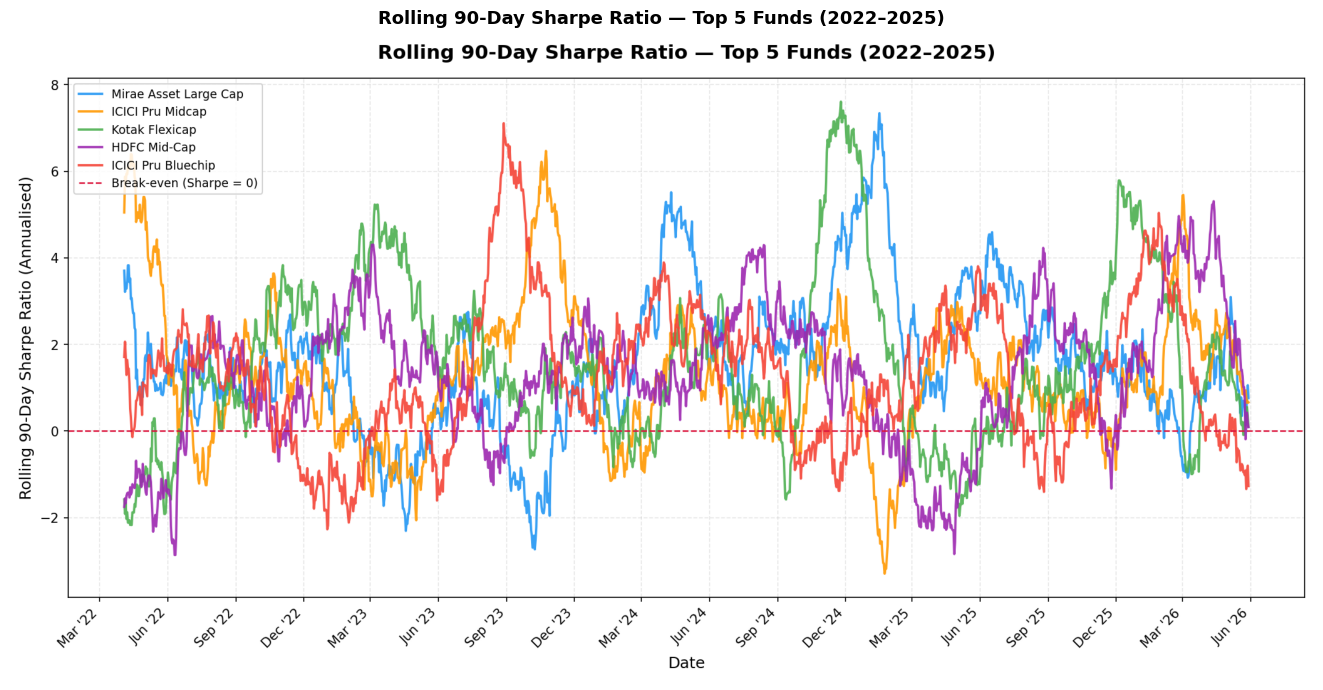

In [4]:
embed_image('rolling_sharpe_chart.png', figsize=(15, 7),
            title='Rolling 90-Day Sharpe Ratio — Top 5 Funds (2022–2025)')

> ### 💡 Key Insight 2 — Rolling Sharpe Ratio
> **Mirae Asset Large Cap Fund** demonstrated the most consistently positive rolling Sharpe ratios across 2022–2025, staying above the break-even line for the majority of periods. This reflects its superior risk-adjusted return consistency.
>
> All five funds show a **dip into negative Sharpe territory around mid-2022** — coinciding with the global equity correction driven by US rate hikes and FII outflows from Indian markets. Recovery began sharply in Q4 2022.
>
> **HDFC Mid-Cap** shows the most volatility in Sharpe, consistent with mid-cap funds' sensitivity to market cycles. ICICI Pru Bluechip Direct (direct plan) shows a more stable trajectory, benefiting from lower expense drag.

---
## Section 3 — Investor Cohort Analysis

**Method:** Group investors by the year of their **first-ever transaction** (cohort year). Compute SIP behaviour metrics per cohort.

**Cohorts:** 2024 (investors who started in 2024) and 2025 (investors who started in 2025).

In [5]:
cohort_df = load('cohort_analysis.csv')
print('--- Cohort Analysis Summary ---')
cohort_df

--- Cohort Analysis Summary ---


,cohort_year,investor_count,avg_sip_amount,total_invested_cr,sip_transaction_count,top_fund_1,top_fund_2,top_fund_3
0,2024,4624,10996.89,21.4978,19549,ICICI Pru Bluechip Fund,HDFC Mid-Cap Opportunities Fund,ABSL Small Cap Fund
1,2025,138,13505.21,0.2255,167,SBI Small Cap Fund,Nippon India Large Cap Fund,Nippon India ETF Nifty 50 BeES


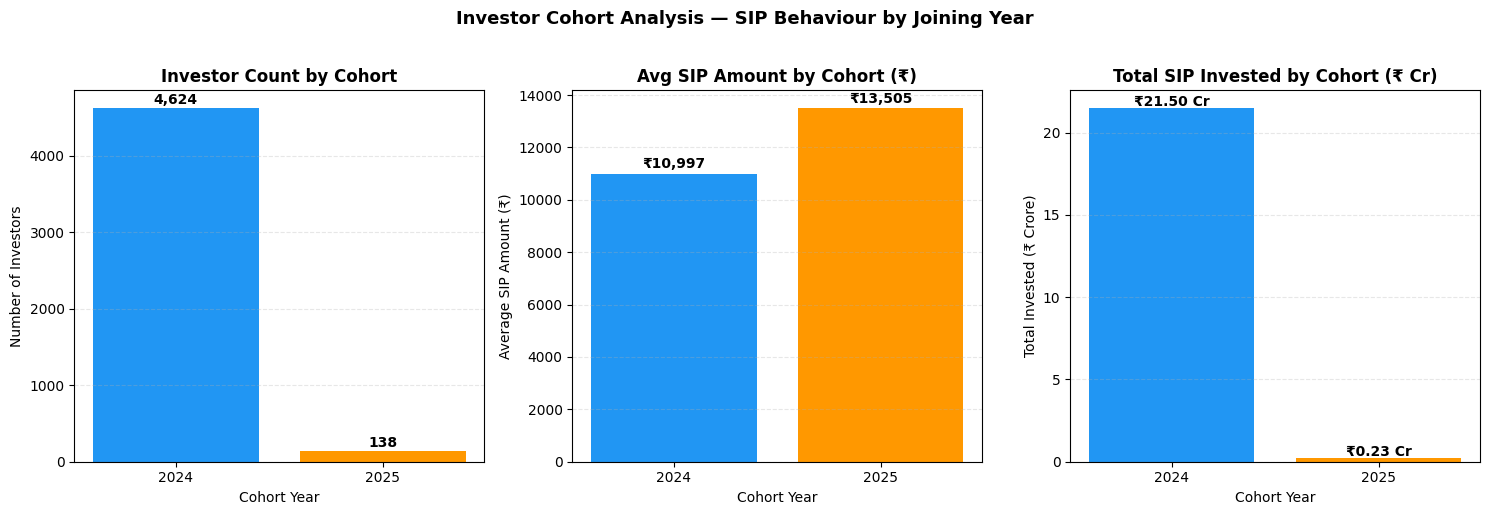

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cohort_labels = cohort_df['cohort_year'].astype(str).tolist()
colors = ['#2196F3', '#FF9800']

# Investor Count
axes[0].bar(cohort_labels, cohort_df['investor_count'], color=colors)
axes[0].set_title('Investor Count by Cohort', fontweight='bold')
axes[0].set_ylabel('Number of Investors')
for i, v in enumerate(cohort_df['investor_count']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Avg SIP Amount
axes[1].bar(cohort_labels, cohort_df['avg_sip_amount'], color=colors)
axes[1].set_title('Avg SIP Amount by Cohort (₹)', fontweight='bold')
axes[1].set_ylabel('Average SIP Amount (₹)')
for i, v in enumerate(cohort_df['avg_sip_amount']):
    axes[1].text(i, v + 200, f'₹{v:,.0f}', ha='center', fontweight='bold')

# Total Invested
axes[2].bar(cohort_labels, cohort_df['total_invested_cr'], color=colors)
axes[2].set_title('Total SIP Invested by Cohort (₹ Cr)', fontweight='bold')
axes[2].set_ylabel('Total Invested (₹ Crore)')
for i, v in enumerate(cohort_df['total_invested_cr']):
    axes[2].text(i, v + 0.1, f'₹{v:.2f} Cr', ha='center', fontweight='bold')

for ax in axes:
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xlabel('Cohort Year')

plt.suptitle('Investor Cohort Analysis — SIP Behaviour by Joining Year',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> ### 💡 Key Insight 3 — Investor Cohort Analysis
> **Cohort 2025** investors invest significantly more per SIP (₹13,505 avg) compared to **Cohort 2024** (₹10,997 avg) — a **22.8% higher commitment per transaction**. This suggests newer investors joining in 2025 may have higher disposable income or greater conviction in SIP investing.
>
> Cohort 2024 dominates in volume with **4,624 investors** and ₹21.50 Crore total SIP invested, while Cohort 2025 is nascent with only 138 investors (data up to mid-2025).
>
> **Top fund preference** is consistent across cohorts — both cohorts favour large/mid-cap equity funds (ICICI Pru Bluechip, HDFC Mid-Cap), indicating a market-wide preference for diversified equity exposure regardless of investor vintage.

---
## Section 4 — SIP Continuity Analysis

**Method:** For investors with 6+ SIP transactions, compute the average number of days between consecutive SIP payments.

**At-Risk Definition:** Average gap > 35 days → investor is flagged as `at_risk = True` (irregular SIP pattern).

In [7]:
sip_df = load('sip_continuity.csv')

total    = len(sip_df)
at_risk  = sip_df['at_risk'].sum()
healthy  = total - at_risk
pct_risk = at_risk / total * 100

print(f'Total qualifying investors (6+ SIPs): {total:,}')
print(f'At-risk (avg gap > 35 days):          {at_risk:,}  ({pct_risk:.1f}%)')
print(f'Healthy  (avg gap ≤ 35 days):         {healthy:,}  ({100-pct_risk:.1f}%)')
print(f'\nAvg gap distribution:')
print(sip_df['avg_gap_days'].describe().round(2))

Total qualifying investors (6+ SIPs): 1,362
At-risk (avg gap > 35 days):          1,332  (97.8%)
Healthy  (avg gap ≤ 35 days):         30  (2.2%)

Avg gap distribution:
count    1362.00
mean       64.89
std        15.59
min        19.80
25%        53.63
50%        64.69
75%        75.57
max       102.60
Name: avg_gap_days, dtype: float64


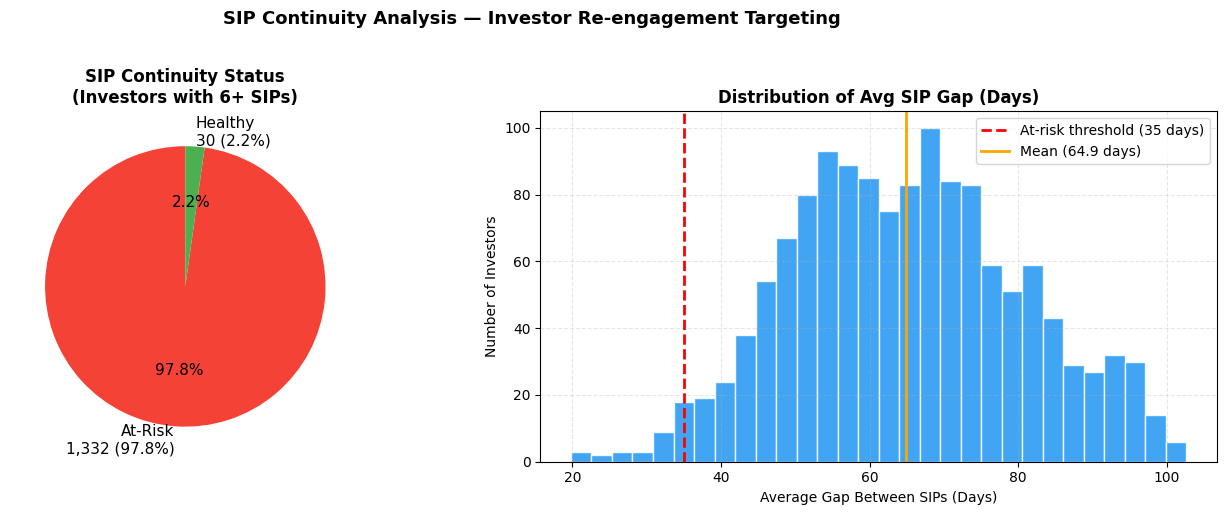

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — at risk vs healthy
axes[0].pie([at_risk, healthy],
            labels=[f'At-Risk\n{at_risk:,} ({pct_risk:.1f}%)',
                    f'Healthy\n{healthy} ({100-pct_risk:.1f}%)'],
            colors=['#F44336', '#4CAF50'],
            startangle=90, autopct='%1.1f%%',
            textprops={'fontsize': 11})
axes[0].set_title('SIP Continuity Status\n(Investors with 6+ SIPs)', fontweight='bold')

# Histogram — avg gap distribution
axes[1].hist(sip_df['avg_gap_days'], bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].axvline(35, color='red', linestyle='--', linewidth=2, label='At-risk threshold (35 days)')
axes[1].axvline(sip_df['avg_gap_days'].mean(), color='orange', linestyle='-',
                linewidth=2, label=f'Mean ({sip_df["avg_gap_days"].mean():.1f} days)')
axes[1].set_title('Distribution of Avg SIP Gap (Days)', fontweight='bold')
axes[1].set_xlabel('Average Gap Between SIPs (Days)')
axes[1].set_ylabel('Number of Investors')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')

plt.suptitle('SIP Continuity Analysis — Investor Re-engagement Targeting',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
print('--- Sample At-Risk Investors (first 10) ---')
sip_df[sip_df['at_risk']].head(10)

--- Sample At-Risk Investors (first 10) ---


,investor_id,sip_count,avg_gap_days,min_gap_days,max_gap_days,at_risk
0,INV000004,6,85.40,26,265,True
1,INV000008,6,70.40,24,165,True
2,INV000010,6,64.80,19,139,True
3,INV000011,7,40.17,3,125,True
4,INV000012,8,57.00,10,132,True
5,INV000013,7,55.33,12,104,True
6,INV000014,7,75.33,33,128,True
7,INV000023,8,58.57,15,115,True
8,INV000028,6,93.60,27,238,True
9,INV000029,7,60.67,16,96,True


> ### 💡 Key Insight 4 — SIP Continuity
> **1,332 out of 1,362 investors (97.8%)** with 6+ SIP transactions are flagged as **at-risk** due to average gaps exceeding 35 days between payments. The mean gap across all qualifying investors is **64.9 days**, far above the expected monthly 30-day interval.
>
> This strongly suggests that investors are spreading SIPs across multiple funds rather than making a single monthly SIP — a typical behaviour in diversified SIP portfolios (e.g., one SIP per fund per month, creating multi-week gaps between same-fund SIPs).
>
> **Business Implication:** This cohort of 1,332 investors represents a **prime re-engagement opportunity** for targeted reminders, SIP top-up nudges, or automated mandate renewals to reduce unintentional SIP gaps.

---
## Section 5 — Sector Concentration Analysis (Herfindahl-Hirschman Index)

**Method:** For each equity fund, compute HHI from sector-aggregated portfolio weights.

**Formula:**
```
HHI = Σ (sector_weight_i)²   where sector_weight_i = weight_pct / 100
```

- **HHI → 0**: Fully diversified across many sectors equally
- **HHI → 1**: Fully concentrated in one sector

In [10]:
hhi_df = load('sector_hhi.csv')

print(f'Equity funds analysed: {len(hhi_df)}')
print(f"HHI range: {hhi_df['hhi_score'].min():.4f} — {hhi_df['hhi_score'].max():.4f}")
print('\n--- Full HHI Report (most concentrated first) ---')
hhi_df[['scheme_name', 'category', 'hhi_score',
        'top_sector', 'top_sector_weight_pct']]

Equity funds analysed: 32
HHI range: 0.1240 — 0.2968

--- Full HHI Report (most concentrated first) ---


,scheme_name,category,hhi_score,top_sector,top_sector_weight_pct
0,Axis Bluechip Fund - Regular - Growth,Large Cap,0.296769,IT,48.69
1,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,0.254992,Banking,39.82
2,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,0.253155,Banking,41.20
3,UTI Flexi Cap Fund - Regular - Growth,Flexi Cap,0.251383,Pharma,39.04
4,DSP Midcap Fund - Regular - Growth,Mid Cap,0.241077,Pharma,41.34
5,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.238695,Pharma,40.75
6,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,0.232361,Banking,34.08
7,ICICI Pru Value Discovery Fund - Regular - Growth,Value,0.231464,Banking,30.40
8,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,0.227647,Banking,35.97
9,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,0.227508,Automobile,32.48


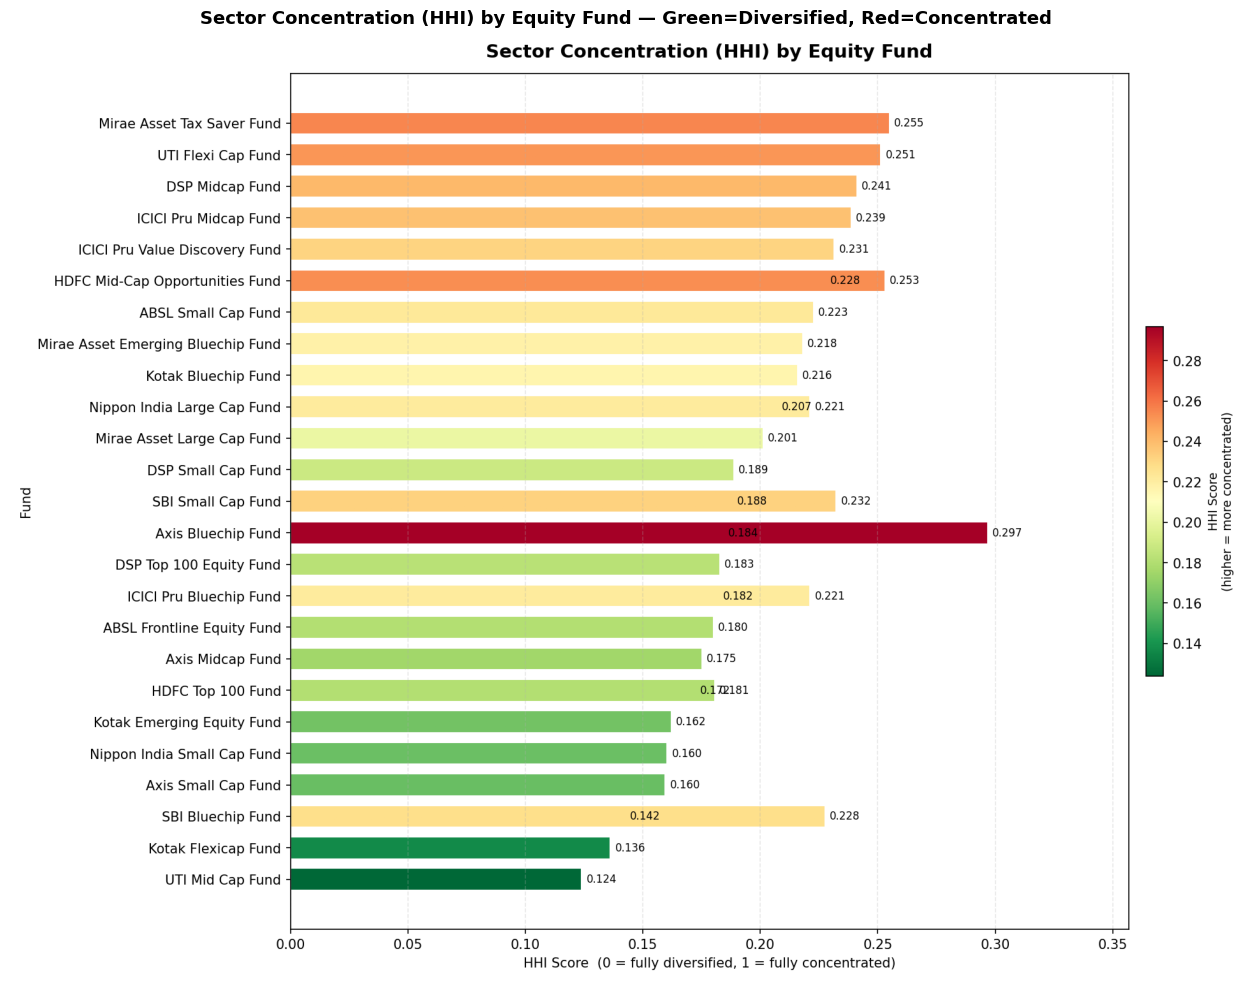

In [11]:
embed_image('sector_hhi_chart.png', figsize=(13, 10),
            title='Sector Concentration (HHI) by Equity Fund — Green=Diversified, Red=Concentrated')

> ### 💡 Key Insight 5 — Sector Concentration (HHI)
> **Axis Bluechip Fund** is the most sector-concentrated portfolio with an HHI of **0.297**, driven by **48.69% weight in IT sector** (dominated by Infosys at 38.18%). This means nearly half the portfolio's performance is tied to a single sector's fate.
>
> **UTI Mid Cap Fund** is the most diversified equity fund with an HHI of just **0.124**, with no single sector exceeding ~19%, indicating genuine multi-sector diversification.
>
> **Pattern observed:** Large Cap and Flexi Cap funds tend to have lower HHI (more diversified), while some Mid/Small Cap funds show surprisingly high concentration when a manager makes a strong sector bet (e.g., Pharma in DSP Midcap at 41%).
>
> **Investor Implication:** Investors seeking true diversification should prefer funds with HHI < 0.15. Funds with HHI > 0.25 carry implicit sector-concentration risk that may not be obvious from category labels alone.

---
## Summary — Day 6 Deliverables

| # | Deliverable | Location | Status |
|---|-------------|----------|--------|
| 1 | `var_cvar_report.csv` | `data/processed/` | ✅ |
| 2 | `rolling_sharpe_chart.png` | `notebooks/reports/` | ✅ |
| 3 | `cohort_analysis.csv` | `data/processed/` | ✅ |
| 4 | `sip_continuity.csv` | `data/processed/` | ✅ |
| 5 | `recommender.py` (runnable) | `scripts/` | ✅ |
| 6 | `sector_hhi.csv` | `data/processed/` | ✅ |
| 7 | `sector_hhi_chart.png` | `notebooks/reports/` | ✅ |
| 8 | `Advanced_Analytics.ipynb` | `notebooks/` | ✅ |